In [1]:
# using Pkg
# Pkg.activate("/home/jek354/research/ML-signproblem")
# Pkg.update()

using Lattices
using LinearAlgebra
using Combinatorics
using SparseArrays
using Plots
import Graphs
using LaTeXStrings
using Statistics
using Random
using Zygote
using Optimization, OptimizationOptimisers
using JSON
using OptimizationOptimJL
using JLD2
using ExponentialUtilities


include("ed_objects.jl")
include("ed_functions.jl")
include("ed_optimization.jl")
include("utility_functions.jl")

merge_jld2_folder

In [2]:
electrons = (3,3)
file_label = "N=$(electrons)_3x2"
folder = "data/$(file_label)_3"
# folder="data/tmp"

e_metadata = load_saved_dict(joinpath(folder, "meta_data_and_E.jld2"))
U_values = e_metadata["meta_data"]["U_values"]
dim = [parse(Int, x) for x in split(e_metadata["meta_data"]["sites"], "x")]
shared_data = load_saved_dict(joinpath(folder, "unitary_map_energy_symmetry=false_N=$(electrons)_shared.jld2"))
coefficient_data = []
interaction_data = []
loss1 = []
loss2 = []
initial_loss = [] 
for i = 2:60#2:61
    dic = load_saved_dict(joinpath(folder, "unitary_map_energy_symmetry=false_N=$(electrons)_u_$i.jld2"))
    push!(coefficient_data, dic["coefficients"][2])
    push!(interaction_data, U_values[i])
    push!(loss1, dic["metrics"]["loss"][2])
    if length(dic["metrics"]["loss"]) > 2
        push!(loss2, dic["metrics"]["loss"][3])
    end
    push!(initial_loss, dic["metrics"]["loss"][1])
end
coefficient_data = reduce(hcat, coefficient_data);

U=2.8263157894736843
0.41231056256176607


0.41231056256176607
2.1
1.2529964086141667
2.1
2.1


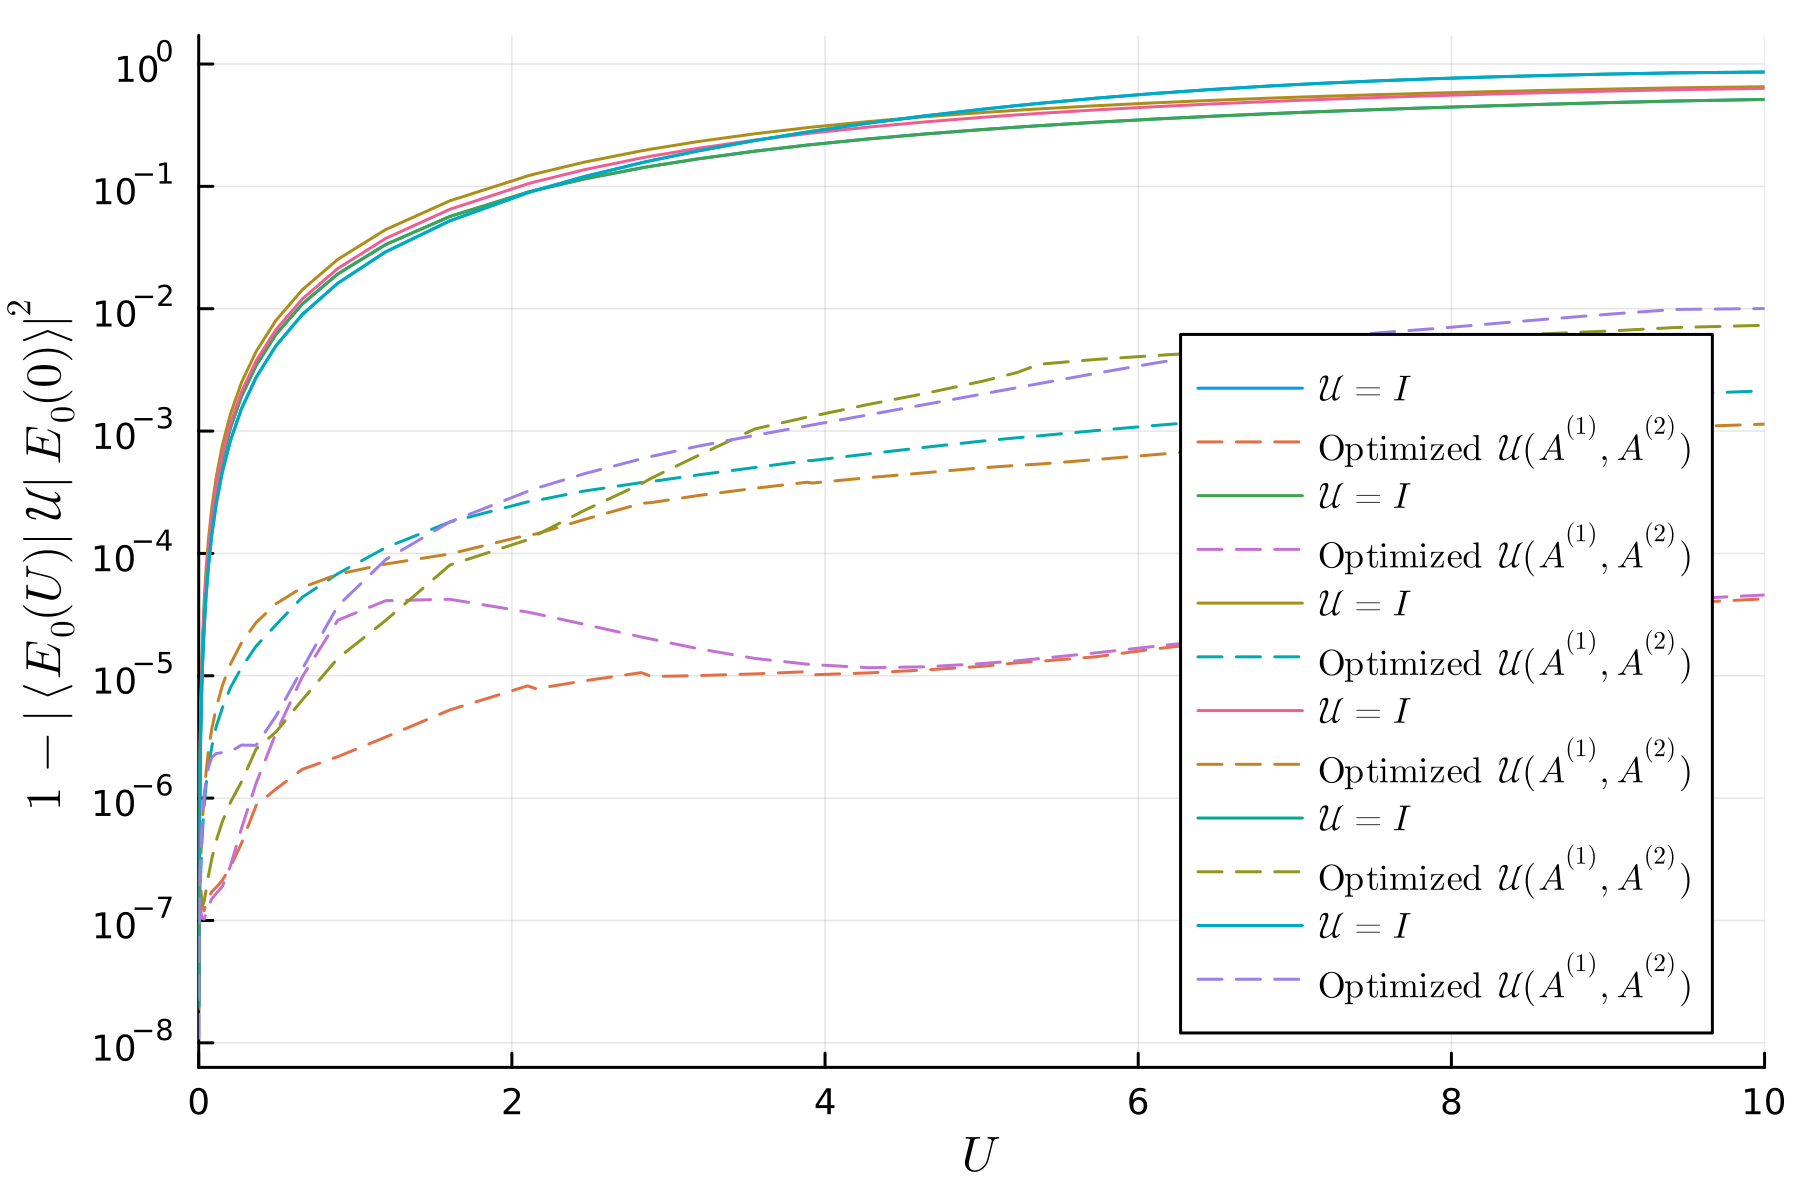

"/home/jek354/research/ML-signproblem/experimenting/ed/good_images/extras/U=2.8263157894736843_relative_loss.pdf"

In [22]:
# p = plot(dpi=300, xlim=(0,10),ylabel=L"1-|\langle E_0(U)|\mathcal{U}|E_0(0)\rangle|^2", xlabel=L"U", legend=:bottomright,
#     yticks=10. .^(-10:0),
#     yscale=:log10,
# )
# plot!(p, interaction_data, initial_loss, linewidth=1, label=L"\mathcal{U}=I")
# plot!(p, interaction_data, loss1,linewidth=1,  label=L"\textrm{Optimized }\;\;\mathcal{U}(A^{(1)},A^{(2)})")
# savefig(p, "good_images/loss_curve_$(file_label)_nonlogscale.png")
# savefig(p, "good_images/loss_curve_$(file_label)_nonlogscale.pdf")
# display(p)
# plot!(interaction_data, loss2, label=L"(n=2)+(n=1)")


p = plot(dpi=300, xlim=(0,10),ylabel=L"1-|\langle E_0(U)|\mathcal{U}|E_0(0)\rangle|^2", xlabel=L"U", legend=:bottomright,
    yticks=10. .^(-10:0),
    yscale=:log10,
)
file_label_pair = [
    (L"N_\uparrow=3, N_\downarrow=3, 3\times 2","N=(3, 3)_3x2_3", (3,3)), 
    (L"N_\uparrow=3, N_\downarrow=3, 3\times2","N=(3, 3)_3x2_2", (3,3)),
    (L"N_\uparrow=4, N_\downarrow=4, 3\times3", "N=(4, 4)_3x3_2", (4,4)),
    (L"N_\uparrow=4, N_\downarrow=4, 4\times2", "N=(4, 4)_4x2_2", (4,4)),
    (L"N_\uparrow=4, N_\downarrow=5, 3\times3", "N=(4, 5)_3x3_3", (4,5)),
    (L"N_\uparrow=4, N_\downarrow=5, 3\times3", "N=(4, 5)_3x3", (4,5)),
    ]

i = 30
println("U=$(interaction_data[i])")
for (label,file_label, electrons) in file_label_pair

    folder = "/home/jek354/research/ML-signproblem/experimenting/ed/data"
    d = load(joinpath(folder, "$(file_label)/meta_data_and_E.jld2"))["dict"]
    hilbert_space_size = size(d["all_full_eig_vecs"][1],2)
    line_width = sqrt(hilbert_space_size)/20
    println(line_width)

    loss1 = []
    loss2 = []
    initial_loss = [] 
    for i = 2:60#2:61
        dic = load_saved_dict(joinpath(folder,file_label, "unitary_map_energy_symmetry=false_N=$(electrons)_u_$i.jld2"))
        push!(loss1, dic["metrics"]["loss"][2])
        if length(dic["metrics"]["loss"]) > 2
            push!(loss2, dic["metrics"]["loss"][3])
        end
        push!(initial_loss, dic["metrics"]["loss"][1])
    end

    plot!(p, interaction_data, initial_loss, linewidth=1, label=L"\mathcal{U}=I")
    plot!(p, interaction_data, loss1,linewidth=1,  label=L"\textrm{Optimized }\;\;\mathcal{U}(A^{(1)},A^{(2)})", linestyle=:dash)

end
display(p)
savefig("good_images/extras/U=$(interaction_data[i])_relative_loss.png")
savefig("good_images/extras/U=$(interaction_data[i])_relative_loss.pdf")


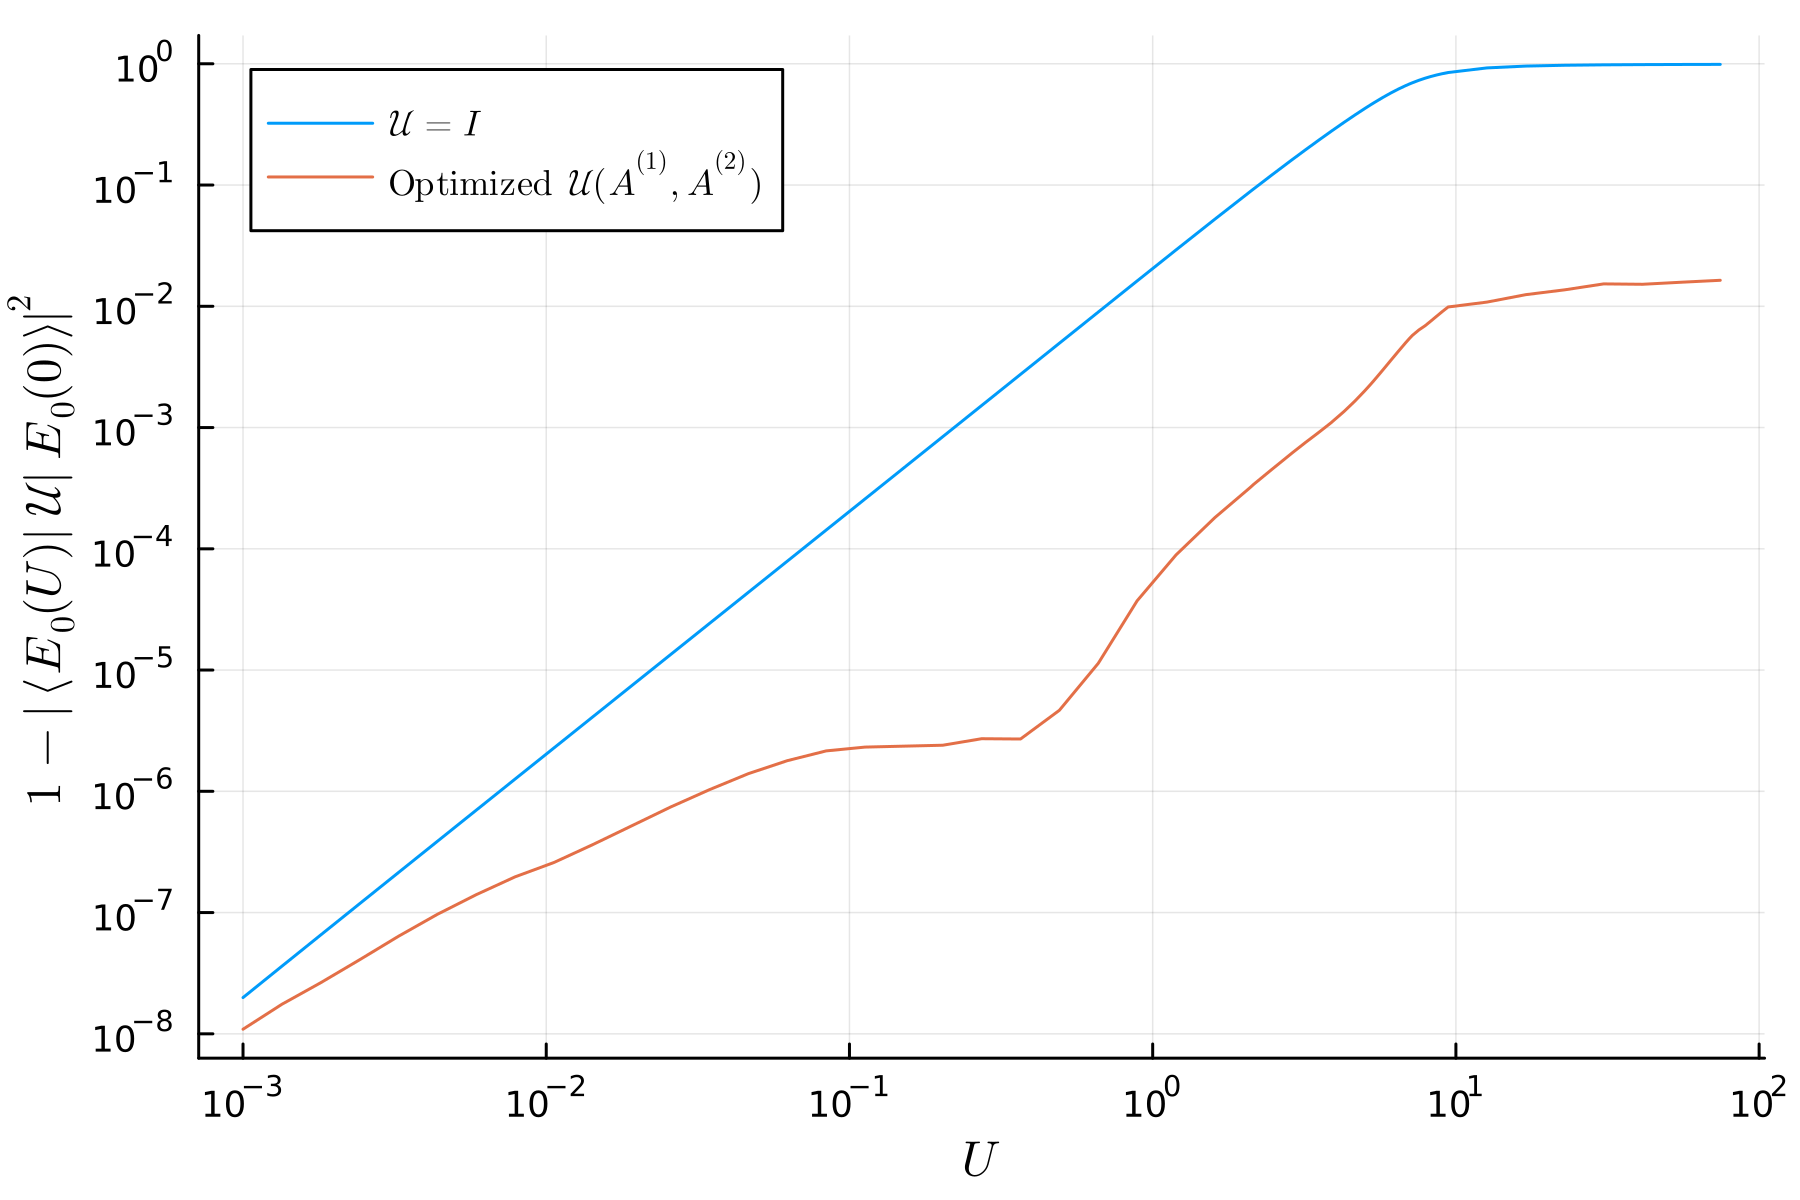

In [66]:
p = plot(yscale=:log10, dpi=300, xscale=:log10, ylabel=L"1-|\langle E_0(U)|\mathcal{U}|E_0(0)\rangle|^2", xlabel=L"U", yticks=10.0 .^(-10:0), xticks=10.0 .^(-3:3), legend=:topleft)
plot!(p, interaction_data, initial_loss, label=L"\mathcal{U}=I")
plot!(p, interaction_data, loss1, label=L"\textrm{Optimized }\;\;\mathcal{U}(A^{(1)},A^{(2)})")
savefig(p, "good_images/extras/loss_curve_$(file_label).png")
savefig(p, "good_images/extras/loss_curve_$(file_label).pdf")
display(p)
# plot!(interaction_data, loss2, label=L"(n=2)+(n=1)")


In [4]:
# u_data["coefficient_values"][2]

using Plots
using LaTeXStrings


order = 2
x = []
y = []
z = []
z1 = []
z2 = []
target_spin = 3 .-[1,2,1,2]
selected_coefficient_index = falses(length(shared_data["coefficient_labels"][2])) # to filter spins
for i in eachindex(if shared_data["coefficient_labels"][order] !== nothing shared_data["coefficient_labels"][order] else [] end)
    # k1 + k2 -> k1' + k2'
    if !all(shared_data["coefficient_labels"][2][i][term][2] == target_spin[term] for term in 1:4)
        continue
    end
    # display(shared_data["coefficient_labels"][2][i])
    s = sum(abs2, (collect((shared_data["coefficient_labels"][2][i][1][1] +  shared_data["coefficient_labels"][2][i][2][1]).coordinates) .- 2)) # (k1 + k2)^2
    t = sum(abs2, (shared_data["coefficient_labels"][2][i][1][1] -  shared_data["coefficient_labels"][2][i][1+order][1]).coordinates) # (k1 - k1')^2
    u = sum(abs2, (shared_data["coefficient_labels"][2][i][1][1] -  shared_data["coefficient_labels"][2][i][2+order][1]).coordinates) # (k1 - k2')^2
    # println("($s, $t, $u): $(u_data["coefficient_values"][2][i])")

    # push!(x, (u -t)+(rand()*2-1)*0.2)
    push!(x, s)
    push!(y, t)
    push!(z, u)
    # push!(y, s+(rand()*2-1)*0.2)
    selected_coefficient_index[i] = true

end


# scatter(x,y,z, marker_z=coefficient_data[selected_coefficient_index, 1], color=:balance,xlabel=L"s", ylabel=L"t", zlabel="u")

high_range_mask = abs.(coefficient_data[:, 50]) .> 0.2
mid_range_mask = 0.05 .< abs.(coefficient_data[:, 50]) .< 0.2
low_range_mask = abs.(coefficient_data[:, 50]) .< 0.05
# histogram(abs.(coefficient_data[selected_coefficient_index, 50]), bins=30)

for i in eachindex(selected_coefficient_index)
    if !selected_coefficient_index[i] || !high_range_mask[i] 
        continue
    end
    display(shared_data["coefficient_labels"][2][i])
end

4-element Vector{Tuple{Coordinate{2, Int64}, Int64, Symbol}}:
 (Coordinate(1, 2), 2, :create)
 (Coordinate(1, 3), 1, :create)
 (Coordinate(1, 2), 2, :annihilate)
 (Coordinate(1, 3), 1, :annihilate)

4-element Vector{Tuple{Coordinate{2, Int64}, Int64, Symbol}}:
 (Coordinate(1, 2), 2, :create)
 (Coordinate(1, 3), 1, :create)
 (Coordinate(2, 1), 2, :annihilate)
 (Coordinate(3, 1), 1, :annihilate)

4-element Vector{Tuple{Coordinate{2, Int64}, Int64, Symbol}}:
 (Coordinate(1, 2), 2, :create)
 (Coordinate(1, 3), 1, :create)
 (Coordinate(2, 3), 2, :annihilate)
 (Coordinate(3, 2), 1, :annihilate)

4-element Vector{Tuple{Coordinate{2, Int64}, Int64, Symbol}}:
 (Coordinate(1, 2), 2, :create)
 (Coordinate(2, 2), 1, :create)
 (Coordinate(3, 1), 2, :annihilate)
 (Coordinate(3, 3), 1, :annihilate)

4-element Vector{Tuple{Coordinate{2, Int64}, Int64, Symbol}}:
 (Coordinate(1, 2), 2, :create)
 (Coordinate(3, 2), 1, :create)
 (Coordinate(2, 1), 2, :annihilate)
 (Coordinate(2, 3), 1, :annihilate)

4-element Vector{Tuple{Coordinate{2, Int64}, Int64, Symbol}}:
 (Coordinate(1, 3), 2, :create)
 (Coordinate(2, 3), 1, :create)
 (Coordinate(3, 1), 2, :annihilate)
 (Coordinate(3, 2), 1, :annihilate)

4-element Vector{Tuple{Coordinate{2, Int64}, Int64, Symbol}}:
 (Coordinate(1, 3), 2, :create)
 (Coordinate(3, 3), 1, :create)
 (Coordinate(2, 1), 2, :annihilate)
 (Coordinate(2, 2), 1, :annihilate)

4-element Vector{Tuple{Coordinate{2, Int64}, Int64, Symbol}}:
 (Coordinate(2, 1), 2, :create)
 (Coordinate(3, 1), 1, :create)
 (Coordinate(2, 1), 2, :annihilate)
 (Coordinate(3, 1), 1, :annihilate)

In [4]:
# u_data["coefficient_values"][2]

using Plots
using LaTeXStrings


order = 2
u_index = 50
spins = [[1,1,1,1], [2,2,2,2], [1,2,1,2], [2,1,2,1], [1,2,2,1], [2,1,1,2]]
y_coords = [1,2,1,2]
collected_values = zeros(length(spins), 3,3,3)
for (spin_i, target_spin) in enumerate(spins)
    kx_values = []
    selected_coefficient_index = falses(length(shared_data["coefficient_labels"][2])) # to filter spins
    for i in eachindex(if shared_data["coefficient_labels"][order] !== nothing shared_data["coefficient_labels"][order] else [] end)
        # k1 + k2 -> k1' + k2'
        # constrain that it's the target spin
        if !all(shared_data["coefficient_labels"][2][i][term][2] == target_spin[term] for term in 1:4)
            continue
        end

        # constrain ky==0 (slice)
        if !all(shared_data["coefficient_labels"][2][i][term][1].coordinates[2] == y_coords[term] for term in 1:4)
            continue
            
        end

        push!(kx_values, [])
        for j=1:4
            push!(kx_values[end], shared_data["coefficient_labels"][2][i][j][1].coordinates[1]-1)
        end

        selected_coefficient_index[i] = true

        # collect colelcted_values to plot
        _i,_j,_k,_l = kx_values[end] .+ 1
        for swap1 in [1, -1]
            for swap2 in [1, -1]
                first_two = swap1 == 1 ? [_i,_j] : [_j,_i]
                last_two = swap2 == 1 ? [_k,_l] : [_l,_k]
                if (first_two[1] == first_two[2] && swap1 == -1) || (last_two[1] == last_two[2] && swap2 == -1)
                    continue
                end
                collected_values[spin_i,first_two...,last_two[1]] = swap1*swap2*coefficient_data[i, u_index]
            end
        end 
    end


    # scatter(x,y,z, marker_z=coefficient_data[selected_coefficient_index, 1], color=:balance,xlabel=L"s", ylabel=L"t", zlabel="u")
    # println(sum(selected_coefficient_in≥dex))
    for i in eachindex(kx_values)
        tmp_ycoords = y_coords .- 1
        dd = kx_values[i][1] == kx_values[i][3] && tmp_ycoords[1] == tmp_ycoords[3] && kx_values[i][2] == kx_values[i][4] && tmp_ycoords[2] == tmp_ycoords[4]
        onsite = (kx_values[i][1] == kx_values[i][3] == kx_values[i][2] == kx_values[i][4]) && (tmp_ycoords[1]  == tmp_ycoords[2] == tmp_ycoords[3]  == tmp_ycoords[4])
            pairing = (kx_values[i][1] == kx_values[i][2] && tmp_ycoords[1] == tmp_ycoords[2]) && (kx_values[i][3] == kx_values[i][4] && tmp_ycoords[3] == tmp_ycoords[4])
        double_to_split = ((kx_values[i][1] == kx_values[i][2] && tmp_ycoords[1] == tmp_ycoords[2]) || (kx_values[i][3] == kx_values[i][4] && tmp_ycoords[3] == tmp_ycoords[4])) && !dd && !pairing
        label = begin 
            if dd 
                spin_flip = !(target_spin[1] == target_spin[3] && target_spin[2] == target_spin[4])
                "dd($(abs(kx_values[i][1] - kx_values[i][2])),$(abs(tmp_ycoords[1] - tmp_ycoords[2]))) " * (spin_flip ? "spin_flip " : "")  
            else 
                "" 
            end * 
            if onsite
                "onsite " 
            else 
                "" 
            end * 
            if pairing 
                "pairing " 
            else 
                "" 
            end * 
            if double_to_split 
                "double_to_split" 
            else 
                "" 
            end
        end
        println("$target_spin $(kx_values[i]) $(coefficient_data[selected_coefficient_index, :][i, u_index]) $(label)")
    end
end


[1, 1, 1, 1] Any[0, 0, 0, 0] -0.12694092413628152 dd(0,1) 
[1, 1, 1, 1] Any[0, 0, 1, 2] 0.029684379951143074 
[1, 1, 1, 1] Any[0, 1, 0, 1] 0.0029289046227925727 dd(1,1) 
[1, 1, 1, 1] Any[0, 1, 2, 2] 0.14019917953468472 
[1, 1, 1, 1] Any[0, 2, 0, 2] 0.0027849432210014322 dd(2,1) 
[1, 1, 1, 1] Any[0, 2, 1, 1] 0.14019955749324622 
[1, 1, 1, 1] Any[1, 1, 1, 1] -0.016105170571987418 dd(0,1) 
[1, 1, 1, 1] Any[1, 2, 1, 2] 0.05961273809067615 dd(1,1) 
[1, 1, 1, 1] Any[2, 2, 2, 2] -0.015991698654857143 dd(0,1) 
[2, 2, 2, 2] Any[0, 0, 0, 0] -0.12697304098852172 dd(0,1) 
[2, 2, 2, 2] Any[0, 0, 1, 2] 0.029839143327501164 
[2, 2, 2, 2] Any[0, 1, 0, 1] 0.0026220777612702135 dd(1,1) 
[2, 2, 2, 2] Any[0, 1, 2, 2] 0.14034579752745951 
[2, 2, 2, 2] Any[0, 2, 0, 2] 0.0025408385650184952 dd(2,1) 
[2, 2, 2, 2] Any[0, 2, 1, 1] 0.1402715151653646 
[2, 2, 2, 2] Any[1, 1, 1, 1] -0.016140741606114232 dd(0,1) 
[2, 2, 2, 2] Any[1, 2, 1, 2] 0.059298729706991044 dd(1,1) 
[2, 2, 2, 2] Any[2, 2, 2, 2] -0.016000031848

In [ ]:
using Plots.Measures: mm
p = []
for j=1:6
for i=1:3
    push!(p,heatmap(collected_values[j, :,:,i],c=:balance, yticks=[1,2,3], xticks=[1,2,3], clims=(-0.4,0.4),xlabel=L"k^x_1",ylabel=L"k^x_2", title=L"A^{(2)}_{\mathbf{k}_1\mathbf{k}_2\mathbf{k}_3\mathbf{k}_4}c^\dagger_{\mathbf{k}_1}c^\dagger_{\mathbf{k}_2}c_{\mathbf{k}_3}c_{\mathbf{k}_4},\quad k^x_3=%$i \;%$(spins[j])" ))
end
end
plot(p...,layout=(6,3),size=(1200,2000),link=:y, top_margin=0mm,bottom_margin=0mm,left_margin=0mm,right_margin=-5mm)
savefig("coefficients")

"/home/jonathon/Dropbox/programming/cornell courses/research/experimenting/ed/coefficients.png"

In [9]:
p = plot(interaction_data,xlim=(0,10), ylim=(-0.4,0.4),coefficient_data[:, :]', legend=nothing, linewidth=1.5, xlabel=L"U", ylabel=L"A^{(2)}\;\textrm{value}")
savefig(p, "good_images/extras/$(file_label)_coefficient_magnitude_full.png")
# savefig(p, "coefficient_magnitude.pdf")
# display(p)



"/home/jek354/research/ML-signproblem/experimenting/ed/good_images/extras/N=(3, 3)_3x2_coefficient_magnitude_full.png"

In [30]:
n_cols

1

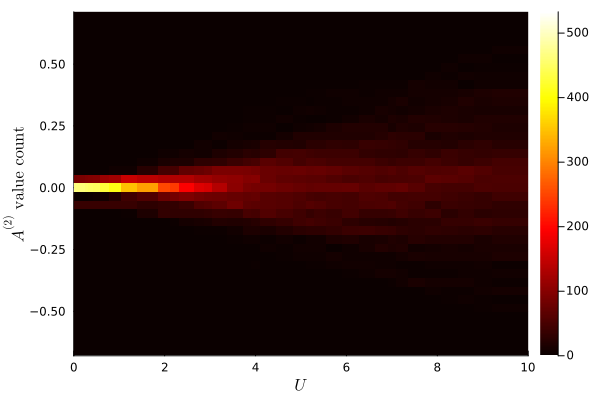

In [67]:
using StatsBase

data = coefficient_data[:,1:53]'
nbins  = 40
lo, hi = minimum(data), maximum(data)
edges  = range(lo, hi, length = nbins + 1)

# 2. Build the counts matrix: (nbins × n_cols)
n_cols = size(data, 1)
counts = zeros(Int, nbins, n_cols)

for i in 1:n_cols
    h = fit(Histogram, data[i, :], edges)
    counts[:, i] = h.weights
end

# 3. Bin centers for the y-axis
bin_centers = (edges[1:end-1] .+ edges[2:end]) ./ 2

# 4. Plot heatmap
#    x → column index (1:n_cols)
#    y → bin centers
#    z → counts matrix
p = heatmap(
    interaction_data[1:53],
    bin_centers,
    counts,
    xlabel = L"U",
    ylabel = L"A^{(2)}\;\textrm{value\;\,count}",
    color  = :hot,
    xlim=(0,10),
)
savefig(p,"good_images/histogram_$(file_label).pdf")
savefig(p,"good_images/histogram_$(file_label).png")
display(p)

In [ ]:
# pruning study
# folder = "/media/jonathon/Jonathon HDD/datasets/HubbardED/N=3" #
folder = raw"C:\Users\jonat\Downloads\N=3"
energy_meta_data_dict = load_saved_dict(joinpath(folder,"meta_data_and_E.jld2"))
degen_rm_U = energy_meta_data_dict["degen_rm_U"]
H = energy_meta_data_dict["H"]
U_values = energy_meta_data_dict["meta_data"]["U_values"]
data = merge_jld2_folder(folder; 
    include_keys=["coefficients", "coefficient_labels", "labels", "all_matrices"], 
    file_filter=[dic -> dic["labels"][1]["starting state"]["level"] == 58 && dic["labels"][1]["ending state"]["level"] == 58],
    verbose=true)

thresholds = 10.0 .^(-10:0.3:0)
# error_data = zeros(length(thresholds), length(U_values))
# original_error_data = zeros(length(U_values))
removed_terms = zeros(length(thresholds), length(U_values))

for k in eachindex(data["coefficients"])
    starting_U_level = data["labels"][1]["starting state"]["level"]
    starting_U_index = data["labels"][1]["starting state"]["U index"]
    ending_U_level = data["labels"][k]["ending state"]["level"]
    ending_U_index = data["labels"][k]["ending state"]["U index"]

    mat_accurate = Matrix(sum(data["all_matrices"][k]))
    found_u_index = data["labels"][k]["ending state"]["U index"]
    n1_overlap_true = energy_meta_data_dict["degen_rm_U"][ending_U_index][:,ending_U_level]' * exp(1im*mat_accurate) * energy_meta_data_dict["degen_rm_U"][starting_U_index][:,starting_U_level]
    # original_error_data[found_u_index] = 1-abs2(n1_overlap_true)
    for (l,threshold) in enumerate(thresholds)
        println("($l,$k) of ($(length(thresholds)), $(length(U_values)))")
        
        removed_terms[l,found_u_index] = sum(sum(abs.(data["coefficients"][k][i]) .< threshold) for i=1:2)
        # println(sum(sum(abs.(data_dict_tmp["coefficients"][1][i]) .< 1e-3) for i=1:2)/sum())

        # n1_overlap = energy_meta_data_dict["degen_rm_U"][ending_U_index][:,ending_U_level]' * exp(1im*mat) * energy_meta_data_dict["degen_rm_U"][starting_U_index][:,starting_U_level]
        # # println(found_u_index)
        # error_data[l,found_u_index]  = 1-abs2(n1_overlap)
    end
end



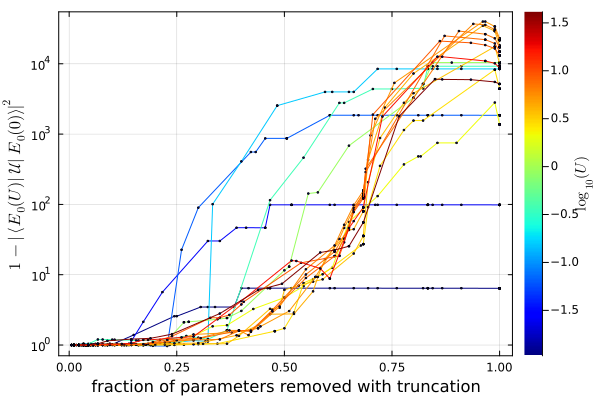

In [7]:
electrons = (3,3)
file_label = "N=$(electrons)_3x2"
folder = "data/$(file_label)_3"

folder = "/home/jek354/research/ML-signproblem/experimenting/ed/data/$(file_label)/pruning_analysis.jld2"
d = load(folder)

#pruning analysis
cmap = cgrad(:jet1, 30, categorical=false)
p = plot( xlabel="fraction of parameters removed with truncation", ylabel=ylabel=L"1-|\langle E_0(U)|\mathcal{U}|E_0(0)\rangle|^2", colorbar_title=L"\log_{10}(U)", framestyle=:box,
    yticks=10.0 .^ (-20:1:10), yscale=:log10)
# )

for i=9:3:59
    filt = d["removed_terms"][:,i] .> 0

    err = max.(abs.(d["error_data"][:,i][filt]),1e-16)
    rel_err = err ./ err[1]
    # println(d["removed_terms"][:,i])
    # println(d["removed_terms"][:,i][filt])
    plot!(p,d["removed_terms"][:,i][filt]./maximum(d["removed_terms"][:,i][filt]),rel_err, line_z=log10.(repeat([interaction_data[i]],sum(filt))),color=cmap, label=nothing, marker=:circle, markersize=1)
end
display(p)

# #pruning analysis
# cmap = cgrad(:jet1, 30, categorical=false)
# p = plot( xlabel="fraction of parameters removed with truncation", ylabel=ylabel=L"1-|\langle E_0(U)|\mathcal{U}|E_0(0)\rangle|^2", colorbar_title=L"\log_{10}(U)", framestyle=:box,
#     yticks=10.0 .^ (-20:3:0), yscale=:log10)
# # )

# p = plot(dpi=200)
# for err in [1e-2]
#     truncation_fraction = []
#     for i=9:59
#         # println(abs.((d["error_data"][1,i] .- d["error_data"][:,i] ) ./ d["error_data"][1,i]) .< 1e-2)
#         j = findlast(abs.((d["error_data"][1,i] .- d["error_data"][:,i] ) ./ d["error_data"][1,i] ).< err)
#         # println(j)
#         push!(truncation_fraction, d["removed_terms"][j,i]./maximum(d["removed_terms"][:,i]))
#     end
#     plot!(p,interaction_data[9:59], truncation_fraction, xlim=(0,10), ylim=(0,0.12),xlabel=L"U", legend=nothing, linewidth=2, ylabel="Truncation fraction to maintain accuracy")
#     savefig(p,"good_images/pruning_analysis_$(file_label).png")
#     savefig(p,"good_images/pruning_analysis_$(file_label).pdf")
# end
# display(p)

U=2.8263157894736843
0.41231056256176607
0.41231056256176607


2.1
1.2529964086141667
2.1
2.1


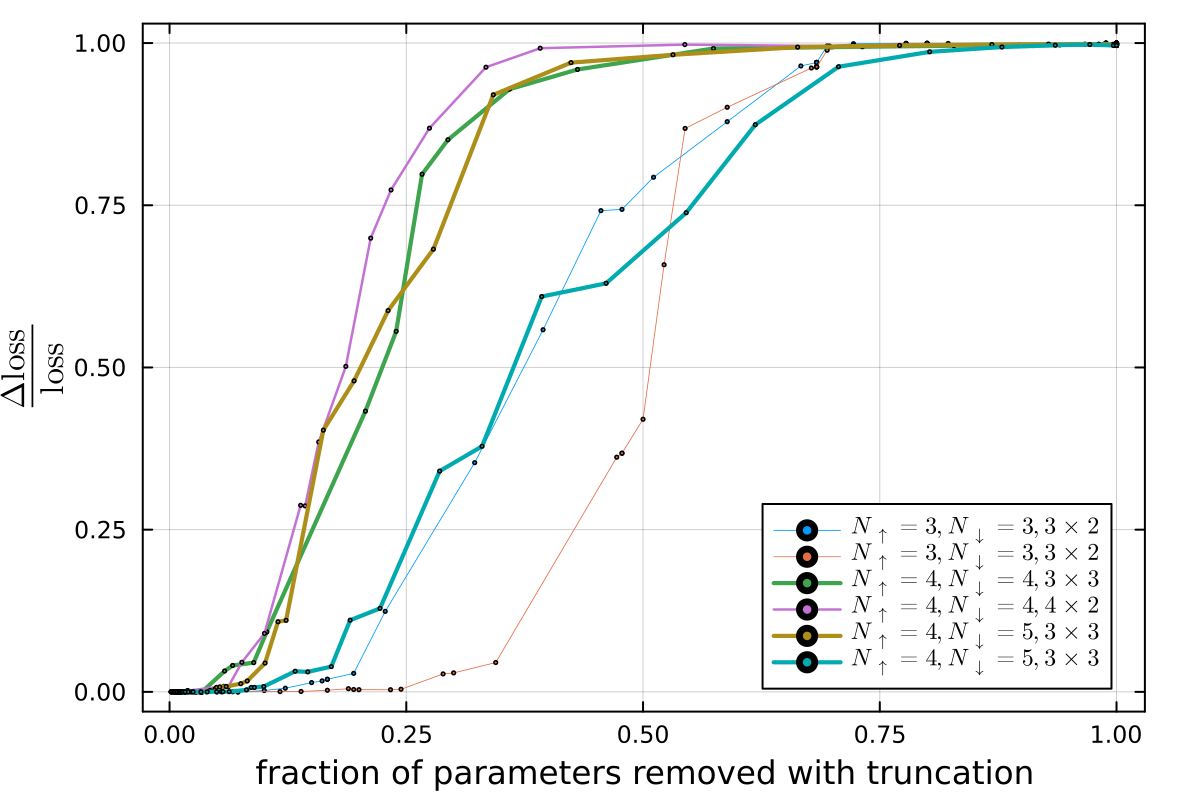

"/home/jek354/research/ML-signproblem/experimenting/ed/good_images/extras/U=2.8263157894736843_relative_loss.pdf"

In [ ]:
using LsqFit
model(x,p) = @. 1/(1+exp(-p[1]*(x-p[2]))^p[3])

electrons = (3,3)
file_label = "N=$(electrons)_3x2"

p = plot( xlabel="fraction of parameters removed with truncation", 
            ylabel=ylabel=L"\frac{\Delta \textrm{loss}}{\textrm{loss}}", 
            # ylabel=L"|\langle E_0(U)|\mathcal{U}|E_0(0)\rangle|^2",
            colorbar_title=L"\log_{10}(U)", framestyle=:box,
    # yticks=10.0 .^ (-20:1:10), 
    # yscale=:log10,
    legend=:bottomright,dpi=200)
# )
file_label_pair = [
    (L"N_\uparrow=3, N_\downarrow=3, 3\times 2","N=(3, 3)_3x2_3"), 
    (L"N_\uparrow=3, N_\downarrow=3, 3\times2","N=(3, 3)_3x2_2"),
    (L"N_\uparrow=4, N_\downarrow=4, 3\times3", "N=(4, 4)_3x3_2"),
    (L"N_\uparrow=4, N_\downarrow=4, 4\times2", "N=(4, 4)_4x2_2"),
    (L"N_\uparrow=4, N_\downarrow=5, 3\times3", "N=(4, 5)_3x3_3"),
    (L"N_\uparrow=4, N_\downarrow=5, 3\times3", "N=(4, 5)_3x3"),
    ]

i = 30
println("U=$(interaction_data[i])")
for (label,file_label) in file_label_pair

    folder = "/home/jek354/research/ML-signproblem/experimenting/ed/data/$(file_label)/pruning_analysis.jld2"
    folder2 = "/home/jek354/research/ML-signproblem/experimenting/ed/data/$(file_label)/meta_data_and_E.jld2"
    d = load(folder2)["dict"]
    hilbert_space_size = size(d["all_full_eig_vecs"][1],2)
    line_width = sqrt(hilbert_space_size)/20
    println(line_width)

    d = load(folder)
 
    filt = d["removed_terms"][:,i] .> 0

    err = max.(abs.(d["error_data"][:,i][filt]),1e-16)
    overlap = 1 .- err
    rel_err = (err .- err[1]) ./ err
    # println(d["removed_terms"][:,i])
    # println(d["removed_terms"][:,i][filt])
    x = d["removed_terms"][:,i][filt]./maximum(d["removed_terms"][:,i][filt])
    y = rel_err

    fit = curve_fit(model, x, y, [1.0,1.0,1.0])
    plot!(p, LinRange(0,1,40), model(LinRange(0,1,40),fit.params), label="fit")
    plot!(p,x,y, linewidth=line_width, label=label, marker=:circle, markersize=1)
end
display(p)
# savefig("good_images/extras/U=$(interaction_data[i])_relative_loss.png")
# savefig("good_images/extras/U=$(interaction_data[i])_relative_loss.pdf")


N=(3, 3)_3x2_3
U=7.017038286703832


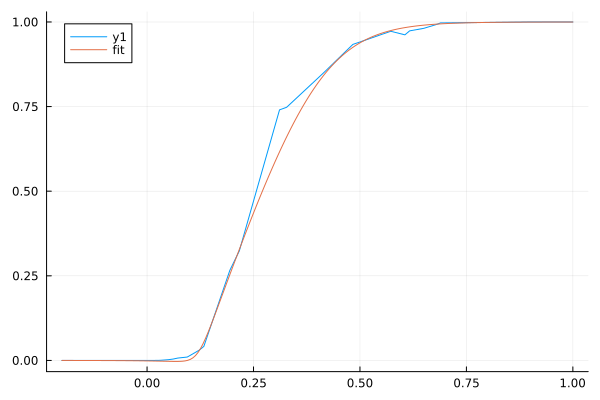

N=(3, 3)_3x2_2
U=7.017038286703832


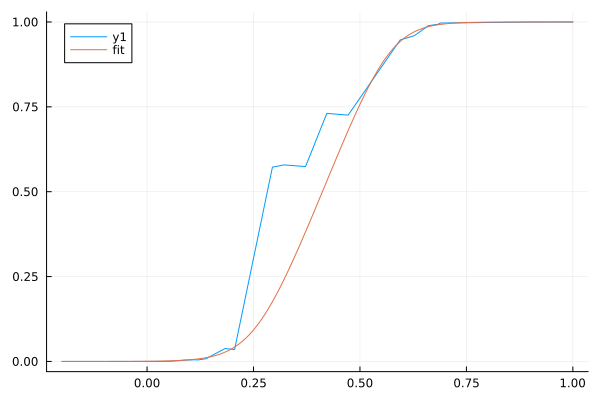

N=(4, 4)_3x3_2
U=7.017038286703832


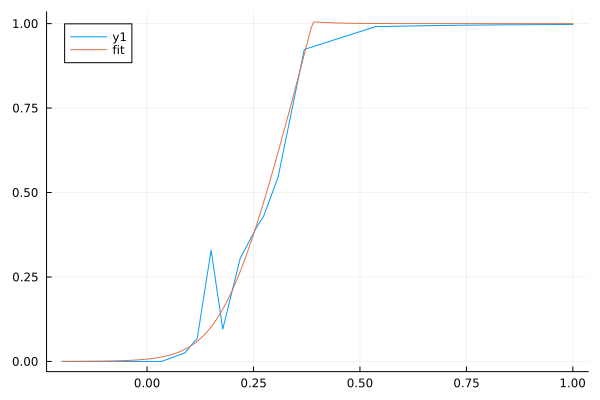

N=(4, 4)_4x2_2
U=7.017038286703832


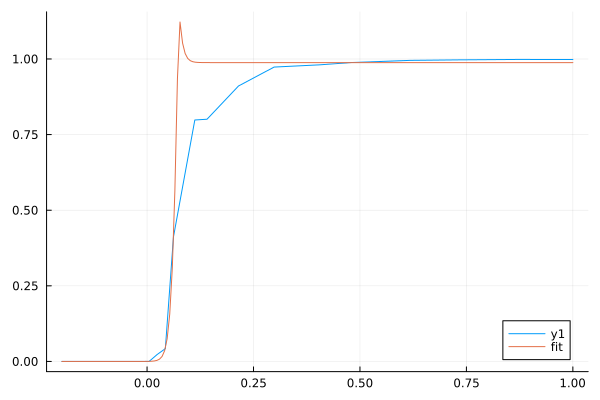

N=(4, 5)_3x3_3
U=7.017038286703832


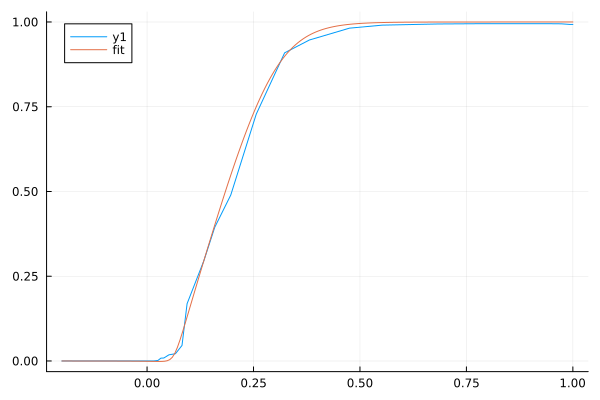

N=(4, 5)_3x3
U=7.017038286703832


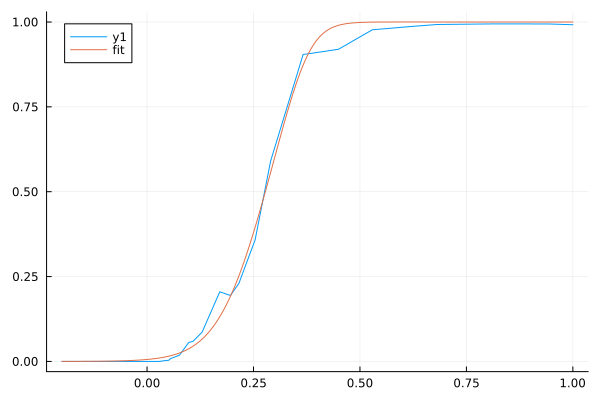

In [2]:
using LsqFit
# using Pkg
# Pkg.activate("/home/jek354/research/ML-signproblem")
# Pkg.update()

using Lattices
using LinearAlgebra
using Combinatorics
using SparseArrays
using Plots
import Graphs
using LaTeXStrings
using Statistics
using Random
using Zygote
using Optimization, OptimizationOptimisers
using JSON
using OptimizationOptimJL
using JLD2
using ExponentialUtilities


include("ed_objects.jl")
include("ed_functions.jl")
include("ed_optimization.jl")
include("utility_functions.jl")

softplus(x) = max(x, zero(x)) + log1p(exp(-abs(x)))
model(x,p) = @. (1/p[1]*softplus(p[1]*(p[3]*(x-p[2]))) - 1/p[4]*softplus(p[4]*(p[3]*(x-p[5]))))/(p[3]*max(p[5]-p[2],1e-2))

electrons = (3,3)
file_label = "N=$(electrons)_3x2"
folder = joinpath(@__DIR__, "data", "$(file_label)_3")
# folder="data/tmp"

e_metadata = load_saved_dict(joinpath(folder, "meta_data_and_E.jld2"))
interaction_data = e_metadata["meta_data"]["U_values"]

file_label_pair = [
    (L"N_\uparrow=3, N_\downarrow=3, 3\times 2","N=(3, 3)_3x2_3"), 
    (L"N_\uparrow=3, N_\downarrow=3, 3\times2","N=(3, 3)_3x2_2"),
    (L"N_\uparrow=4, N_\downarrow=4, 3\times3", "N=(4, 4)_3x3_2"),
    (L"N_\uparrow=4, N_\downarrow=4, 4\times2", "N=(4, 4)_4x2_2"),
    (L"N_\uparrow=4, N_\downarrow=5, 3\times3", "N=(4, 5)_3x3_3"),
    (L"N_\uparrow=4, N_\downarrow=5, 3\times3", "N=(4, 5)_3x3"),
    ]

fit_params = []


for (label,file_label) in file_label_pair
    push!(fit_params, [])
    for i = 25:55

        folder = "/home/jek354/research/ML-signproblem/experimenting/ed/data/$(file_label)/pruning_analysis.jld2"
        folder2 = "/home/jek354/research/ML-signproblem/experimenting/ed/data/$(file_label)/meta_data_and_E.jld2"
        d = load(folder2)["dict"]
        hilbert_space_size = size(d["all_full_eig_vecs"][1],2)
        line_width = sqrt(hilbert_space_size)/20

        d = load(folder)
        filt = d["removed_terms"][:,i] .> 0

        err = max.(abs.(d["error_data"][:,i][filt]),1e-16)
        overlap = 1 .- err
        rel_err = (err .- err[1]) ./ err
        # println(d["removed_terms"][:,i])
        # println(d["removed_terms"][:,i][filt])
        x = d["removed_terms"][:,i][filt]./maximum(d["removed_terms"][:,i][filt])
        y = rel_err

        prepend!(x,[-0.05, -0.1,-0.2])
        prepend!(y,[0.0,0,0])
        filt2 = y .< 0.45 .|| y .>0.9

        fit = curve_fit(model, x[filt2], y[filt2], [20.0,0.2,1,8,0.7], lower=[0.001,-5,1e-4,1e-5,-5], upper=[200.0,5,200,1000,100])
        if i == 46
            println(file_label)
            println("U=$(interaction_data[i])")
            p = plot(x,y)
            plot!(p, LinRange(-0.2,1,200), model(LinRange(-0.2, 1,200),fit.param), label="fit")
            display(p)
        end
        push!(fit_params[end], fit.param)
        
    end
end

# savefig("good_images/extras/U=$(interaction_data[i])_relative_loss.png")
# savefig("good_images/extras/U=$(interaction_data[i])_relative_loss.pdf")





[1.8946361239720115, 1.405296034520717]


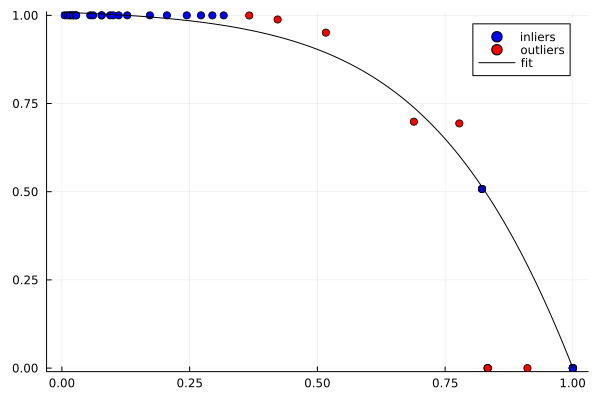

LoadError: DomainError with -9.075817240460809e-6:
log was called with a negative real argument but will only return a complex result if called with a complex argument. Try log(Complex(x)).
DomainError detected in the user `f` function. This occurs when the domain of a function is violated.
For example, `log(-1.0)` is undefined because `log` of a real number is defined to only output real
numbers, but `log` of a negative number is complex valued and therefore Julia throws a DomainError
by default. Cases to be aware of include:

* `log(x)`, `sqrt(x)`, `cbrt(x)`, etc. where `x<0`
* `x^y` for `x<0` floating point `y` (example: `(-1.0)^(1/2) == im`)

Within the context of SciML, this error can occur within the solver process even if the domain constraint
would not be violated in the solution due to adaptivity. For example, an ODE solver or optimization
routine may check a step at `new_u` which violates the domain constraint, and if violated reject the
step and use a smaller `dt`. However, 

In [4]:

softplus(x,b) = max(x, zero(x)) + log(b) + log1p(exp(-abs(x))/b)
scaled_softplus(x, p1, p2) = 1/log(1+p2)*softplus(p1*x, p2)
model(x,p) = @. 1 - (p[6]*scaled_softplus(p[5]*(x-1), p[1], p[2]) + (1-p[6])*scaled_softplus(p[5]*(x-1), p[3], p[4]))
println(scaled_softplus.([1,0.5], 1, 1.0))

electrons = (3,3)
file_label = "N=$(electrons)_3x2"
folder = joinpath(@__DIR__, "data", "$(file_label)_3")
# folder="data/tmp"

e_metadata = load_saved_dict(joinpath(folder, "meta_data_and_E.jld2"))
interaction_data = e_metadata["meta_data"]["U_values"]

file_label_pair = [
    (L"N_\uparrow=3, N_\downarrow=3, 3\times 2","N=(3, 3)_3x2_3"), 
    (L"N_\uparrow=3, N_\downarrow=3, 3\times2","N=(3, 3)_3x2_2"),
    (L"N_\uparrow=4, N_\downarrow=4, 3\times3", "N=(4, 4)_3x3_2"),
    (L"N_\uparrow=4, N_\downarrow=4, 4\times2", "N=(4, 4)_4x2_2"),
    (L"N_\uparrow=4, N_\downarrow=5, 3\times3", "N=(4, 5)_3x3_3"),
    (L"N_\uparrow=4, N_\downarrow=5, 3\times3", "N=(4, 5)_3x3"),
    ]

# fit_params2 = []


for (label,file_label) in file_label_pair
    # push!(fit_params2, [])
    for i = 22:22

        folder = "/home/jek354/research/ML-signproblem/experimenting/ed/data/$(file_label)/pruning_analysis.jld2"
        folder2 = "/home/jek354/research/ML-signproblem/experimenting/ed/data/$(file_label)/meta_data_and_E.jld2"
        d = load(folder2)["dict"]
        hilbert_space_size = size(d["all_full_eig_vecs"][1],2)
        line_width = sqrt(hilbert_space_size)/20

        d = load(folder)
        filt = d["removed_terms"][:,i] .> 0

        err = max.(abs.(d["error_data"][:,i][filt]),1e-16)
        overlap = 1 .- err
        # rel_err = (err .- err[1]) ./ err
        # println(d["removed_terms"][:,i])
        # println(d["removed_terms"][:,i][filt])
        x = d["removed_terms"][:,i][filt]./maximum(d["removed_terms"][:,i][filt])
        y = (overlap .- overlap[end])./(overlap[1] .- overlap[end])


        filt2 = y .>= y[end] #.||(x .< 0.9 .|| x .>= 0.99)

        fit = nothing
        for iter in 1:4
            # Fit the model using the current inliers
            fit = curve_fit(model, x[filt2], y[filt2], [1.0, 1.0, 1.0,1,1,0.5])
            
            # Calculate residuals for ALL data points
            residuals = abs.(y .- model(x, fit.param))
            
            # Use the standard deviation of the current inliers' residuals as a threshold basis
            inlier_std = max(std(residuals[filt2]), 1e-8)
            
            # Keep points that are within 2.0 standard deviations (to remove noise of later data)
            new_filt2 = residuals .<= 3.0 * inlier_std
            
            # Stop if the filter has converged
            if new_filt2 == filt2
                break
            end
            
            # Safety check to avoid dropping too many points
            if sum(new_filt2) < length(fit.param) + 2
                break
            end
            
            filt2 = new_filt2
        end
        fit = curve_fit(model, x[filt2], y[filt2], [1.0, 1.0, 1.0,1,1,0.5])
        
        p = scatter(x[filt2], y[filt2], label="inliers", color=:blue, ylim=(-0.01,1.01))
        if any(.!filt2)
            scatter!(p, x[.!filt2], y[.!filt2], label="outliers", color=:red)
        end
        plot!(p, LinRange(0,1,200), model(LinRange(0, 1,200),fit.param), label="fit", color=:black)
        display(p)
        # push!(fit_params2[end], fit.param)

        
    end
end

# savefig("good_images/extras/U=$(interaction_data[i])_relative_loss.png")
# savefig("good_images/extras/U=$(interaction_data[i])_relative_loss.pdf")





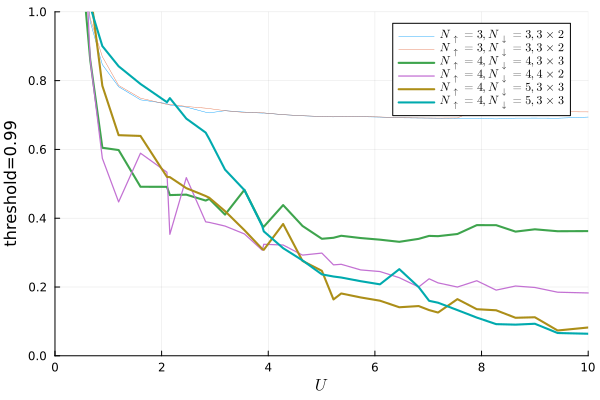

In [71]:
file_label_pair = [
    (L"N_\uparrow=3, N_\downarrow=3, 3\times 2","N=(3, 3)_3x2_3"), 
    (L"N_\uparrow=3, N_\downarrow=3, 3\times2","N=(3, 3)_3x2_2"),
    (L"N_\uparrow=4, N_\downarrow=4, 3\times3", "N=(4, 4)_3x3_2"),
    (L"N_\uparrow=4, N_\downarrow=4, 4\times2", "N=(4, 4)_4x2_2"),
    (L"N_\uparrow=4, N_\downarrow=5, 3\times3", "N=(4, 5)_3x3_3"),
    (L"N_\uparrow=4, N_\downarrow=5, 3\times3", "N=(4, 5)_3x3"),
    ]
function find_root_bisection(f, a, b; tol=1e-5, max_iters=100)
    fa = f(a)
    fb = f(b)
    if sign(fa) == sign(fb)
        return NaN
    end
    for _ in 1:max_iters
        c = (a + b) / 2
        fc = f(c)
        if abs(fc) < tol || (b - a) / 2 < tol
            return c
        end
        if sign(fc) == sign(fa)
            a = c
            fa = fc
        else
            b = c
            fb = fc
        end
    end
    return (a + b) / 2
end

threshold = 0.99
x_thresholds = []

p = plot(ylim=(0,1), xlim=(0,10), xlabel=L"U", ylabel="threshold=0.99")
for (param_u,(label,file_label)) in zip(fit_params2,file_label_pair)

    folder2 = "/home/jek354/research/ML-signproblem/experimenting/ed/data/$(file_label)/meta_data_and_E.jld2"
    d = load(folder2)["dict"]
    hilbert_space_size = size(d["all_full_eig_vecs"][1],2)
    line_width = sqrt(hilbert_space_size)/20

    push!(x_thresholds, Float64[])
    for p in param_u
        # Find x coordinate where model(x, p) is equal to 1 - threshold
        x_val = find_root_bisection(x -> model(x, p) - threshold, -1.0, 2.0)
        push!(x_thresholds[end], x_val)
    end
    plot!(p, interaction_data[22:60], x_thresholds[end], label=label, linewidth=line_width)
end
# savefig("good_images/extras/pruning_data_overlap_thres=0.95.png")
# savefig("good_images/extras/pruning_data_overlap_thres=0.95.pdf")
display(p)

